In [54]:
import torch 
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import MNIST

In [56]:
# Dataset and #Dataloader
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [58]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

trainset = MNIST(root = "./data",train=True,download=True,transform=transform)
testset = MNIST(root = "./data",train=False,download=True,transform=transform)

In [60]:
trainloader = DataLoader(trainset,batch_size=64,shuffle=True)
testloader = DataLoader(testset,batch_size=64)

# CNN

In [61]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
                
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64*5*5,128),
            nn.ReLU(),

            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0),-1)
        x = self.fc_layers(x)
        return x

In [64]:

cnn_model = CNN()
criterian = nn.CrossEntropyLoss()

optimizer = optim.Adam(cnn_model.parameters())


In [65]:
epochs = 5

for epoch in range(epochs):

    epoch_training_loss = 0

    for images, labels in trainloader:
        optimizer.zero_grad()

        outputs = cnn_model.forward(images)
        loss = criterian(outputs,labels)
        loss.backward()
        optimizer.step()

        epoch_training_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} & loss = {epoch_training_loss/len(trainloader)}")

Epoch 1/5 & loss = 0.15688283506210948
Epoch 2/5 & loss = 0.04831705416050325
Epoch 3/5 & loss = 0.032674339753897066
Epoch 4/5 & loss = 0.026035403519259967
Epoch 5/5 & loss = 0.017655402295095206


# RNN

In [66]:
class RNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(28,128,batch_first=True)
        self.fc =nn.Linear(128,10)

    def forward(self,x):
        x = x.squeeze(1)
        out,_ = self.rnn(x)
        out = self.fc(out[:,-1,:])
        return out
        

In [67]:
rnn_model = RNN()
criterian = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model.parameters())


In [68]:
epochs = 5
for epoch in range(epochs):
    for xb, yb in trainloader:
        optimizer.zero_grad()

        outputs = rnn_model(xb)
        loss = criterian(outputs,yb)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} and loss {loss.item()}")

Epoch 1 and loss 0.3155597448348999
Epoch 2 and loss 0.39904046058654785
Epoch 3 and loss 0.19832004606723785
Epoch 4 and loss 0.47040992975234985
Epoch 5 and loss 0.12432245165109634


In [70]:
# CNN COonfusion Metrix
from sklearn.metrics import confusion_matrix, accuracy_score

y_true = []
y_pred = []

with torch.no_grad():
    for x,y in testloader:

        out = cnn_model(x)
        preds = torch.argmax(out,dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())

    cm = confusion_matrix(y_true,y_pred)

    print("Confusion Matrix")
    print(cm)

Confusion Matrix
[[ 979    0    0    0    0    0    1    0    0    0]
 [   0 1132    1    0    0    1    1    0    0    0]
 [   1    0 1028    0    0    0    0    3    0    0]
 [   1    0    2  994    0   10    0    2    1    0]
 [   0    0    0    0  963    0    4    0    0   15]
 [   2    0    1    2    0  885    1    0    0    1]
 [   5    2    0    0    1    4  945    0    1    0]
 [   0    2   15    0    0    0    0  980    3   28]
 [   2    0    1    0    0    1    0    0  967    3]
 [   0    0    1    0    2    3    0    0    1 1002]]


In [71]:
# RNN COnfusion Matrix

y_true = []
y_pred = []

with torch.no_grad():
    for x,y in testloader:

        out = rnn_model(x)
        preds = torch.argmax(out,1)

        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())

    cm = confusion_matrix(y_true,y_pred)

    print("RNN Confusion Matrix")
    print(cm)

RNN Confusion Matrix
[[ 944    0   10    0    4    3   14    1    4    0]
 [   0 1116    1    2    2    4    1    1    8    0]
 [   4    5  976   18    0    4    3    9   13    0]
 [   0    3    4  856    1  100    0    2   11   33]
 [   1    0   10    0  941    1   12    0    7   10]
 [   8    1    0    3    5  819   17    0   32    7]
 [  10    3    2    0    5    1  923    0   14    0]
 [   2   15   35    0    4    8    0  908    5   51]
 [   1    2    8    2    5    2    7    0  940    7]
 [   5    2    4    0  104   18    0    5   18  853]]


In [72]:
# CNN Accuracy
correct = 0
total = 0

with torch.no_grad():
    for x,y in testloader:

        out = cnn_model(x)
        preds = torch.argmax(out,1)

        correct += (preds==y).sum().item()
        total += y.size(0)

    print(f"CNN Accuracy {correct/total*100}")

CNN Accuracy 98.75


In [73]:
# RNN Accuracy
correct = 0
total = 0

with torch.no_grad():
    for x,y in testloader:

        out = rnn_model(x)
        preds = torch.argmax(out,1)

        correct += (preds==y).sum().item()
        total += y.size(0)

    print(f"RNN Accuracy {correct/total*100}")

RNN Accuracy 92.75999999999999


In [85]:
type(cm)

numpy.ndarray

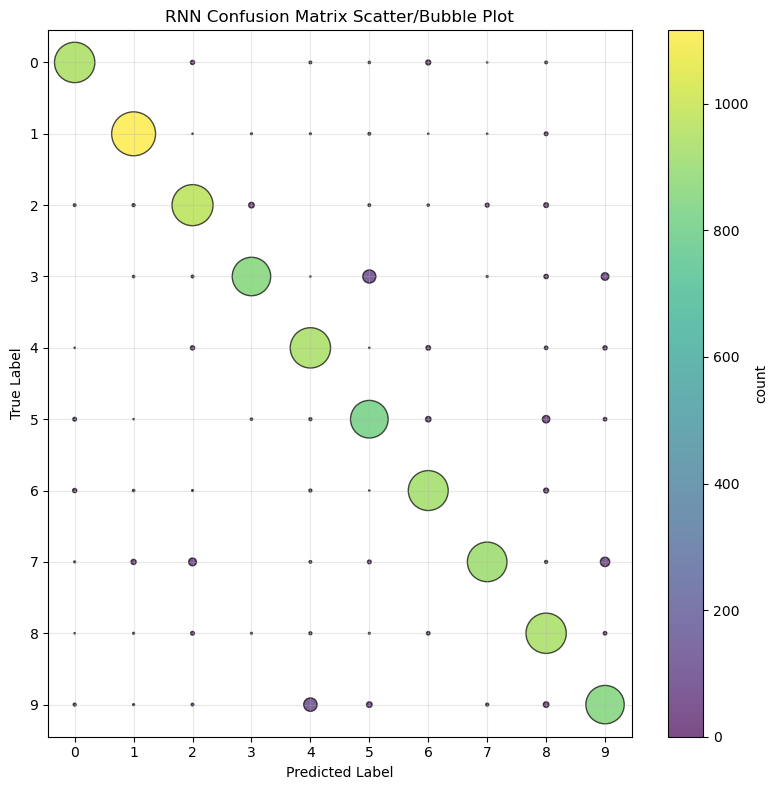

In [87]:
import matplotlib.pyplot as plt
import numpy as np


n_classes = cm.shape[0]

rows,cols = np.meshgrid(np.arange(n_classes),np.arange(n_classes),indexing="ij")
rows = rows.flatten()
cols = cols.flatten()
values = cm.flatten()

plt.figure(figsize=(8,8))
scatter = plt.scatter(
    cols,rows,
    s =values/values.max()*1000,
    c=values,
    cmap= "viridis",
    alpha=0.7,
    edgecolors= "black"
)

plt.colorbar(scatter,label = 'count')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("RNN Confusion Matrix Scatter/Bubble Plot")
plt.gca().invert_yaxis()
plt.xticks(range(n_classes))
plt.yticks(range(n_classes))
plt.grid(True,alpha=0.3)


plt.tight_layout()
plt.show()

In [88]:
torch.save(model, 'mnist_model.pth')